In [ ]:
'''
This is Code Block 1:
It loads up the dataset and sets up the global variables such as categorical features and continous features (Constants).
It also creates sorting/ordering hierarchies for each metric.
'''
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# starting to load our cleaned up dataset
df = pd.read_csv("Cleaned_Topic3_healthcare_analytics_dataset.csv")

print(f"Rows in dataset: {df.shape[0]} .") # just a visual cue to see how many rows. (Not necessary)

'''
Here we start defining our global features: By defining them once here,
future functions can just reference from here. (otherwise, i would have to
pass them in each function and updating any one would be tedious.)
'''

TARGET_VAR = 'Stay' # this is our main/target variable. (constant)

CATEGORICAL_FEATURES = [
    'Hospital_type_code', 'Hospital_region_code', 'Department',
    'Ward_Type', 'Ward_Facility_Code', 'Type of Admission',
    'Severity of Illness', 'Age', 'Bed Grade'
]

CONTINUOUS_FEATURES = [
    'Admission_Deposit',
    'Visitors with Patient',
    'Available Extra Rooms in Hospital'
]


# here we start manually ordering each metric that isnt a value already and skipping the ones we don't need.
# we start with string values and ranges and give them a set order.
stay_order = ['0-10', '11-20', '21-30', '31-40', '41-50', '51-60', '61-70', '71-80', '81-90', '91-100', 'More than 100 Days']
age_order = ['0-10', '11-20', '21-30', '31-40', '41-50', '51-60', '61-70', '71-80', '81-90', '91-100']
severity_order = ['Minor', 'Moderate', 'Extreme']
admission_order = ['Emergency', 'Urgent', 'Trauma']

# these metrics are alphabetical and so they can be sorted into alphabetical sequences.
hospital_type_order = sorted(df['Hospital_type_code'].unique())
region_order = sorted(df['Hospital_region_code'].unique())
dept_order = sorted(df['Department'].unique())
ward_order = sorted(df['Ward_Type'].unique())
facility_order = sorted(df['Ward_Facility_Code'].unique())

# This applies to each metric their respective ordering provided above.
df['Stay'] = pd.Categorical(df['Stay'], categories=stay_order, ordered=True)
df['Age'] = pd.Categorical(df['Age'], categories=age_order, ordered=True)
df['Severity of Illness'] = pd.Categorical(df['Severity of Illness'], categories=severity_order, ordered=True)
df['Type of Admission'] = pd.Categorical(df['Type of Admission'], categories=admission_order, ordered=True)
df['Hospital_type_code'] = pd.Categorical(df['Hospital_type_code'], categories=hospital_type_order, ordered=True)
df['Hospital_region_code'] = pd.Categorical(df['Hospital_region_code'], categories=region_order, ordered=True)
df['Department'] = pd.Categorical(df['Department'], categories=dept_order, ordered=True)
df['Ward_Type'] = pd.Categorical(df['Ward_Type'], categories=ward_order, ordered=True)
df['Ward_Facility_Code'] = pd.Categorical(df['Ward_Facility_Code'], categories=facility_order, ordered=True)


'''
# The following code is calculating and assigning an integer value to the stay order list
for example 0-10 days gets 0 and more than 100+ days gets 10. This is for second order
heatmaps so that pandas knows what to colour eash element based on its stay rank.
'''
df['Stay_Numeric_Rank'] = df['Stay'].cat.codes


Rows in dataset: 313793 .


In [ ]:
'''
This is code block 2, the backend of the whole program. Basically this is where
all the functions and maths for each function is defined. These functions also have their
chart rendering parametres defined here.
'''
# Check to see if the data has been loaded and the global variables are present. (Run Code Block 1)
if 'CATEGORICAL_FEATURES' not in globals():
    raise RuntimeError("Global features missing. You must run Cell 1 first.")

def render_first_order_plot(dataframe, column_name):
    """
    This is the core function for the first-order function. It basically takes exactly
    one metric, calculate how it impacts the length of stay,
    and outputs both a visual chart and a table with mathematical context.
    """
    plot_data = dataframe.copy()

    if column_name in CONTINUOUS_FEATURES:       # this is a binning step where its checking if the metric to plot is categorical or continous.
        if column_name == 'Admission_Deposit':
            plot_data[column_name] = pd.qcut(dataframe[column_name], q=5, duplicates='drop').astype(str) # qcut instead of cut to make equal portions of split based on percentage of patients = 20%
        elif column_name == 'Visitors with Patient':
            plot_data[column_name] = pd.cut(dataframe[column_name], bins=[-1, 2, 4, 6, 10, 100],
                                            labels=['0-2 Visitors', '3-4 Visitors', '5-6 Visitors', '7-10 Visitors', '10+ Visitors']).astype(str)
        elif column_name == 'Available Extra Rooms in Hospital':
            plot_data[column_name] = pd.cut(dataframe[column_name], bins=[-1, 1, 3, 5, 25],
                                            labels=['0-1 Rooms', '2-3 Rooms', '4-5 Rooms', '6+ Rooms']).astype(str)

    crosstab = pd.crosstab(plot_data[column_name], plot_data[TARGET_VAR]) # this is charting selected metric against stay: [column_name] against [target _var]
    crosstab_normalized = crosstab.div(crosstab.sum(1), axis=0) # this is normalising the charts so that they all stretch out to 1 and dont cause an issue where 1 bar has 200,000 patients and another bar has only 1,000 patients. (It actually is the case)

    plt.figure(figsize=(14, 6)) # Just creating the graph.
    crosstab_normalized.plot(kind='bar', stacked=True, colormap='viridis', edgecolor='black', ax=plt.gca())

    plt.title(f"First-Order Correlation: LOS % by '{column_name}'", fontsize=14, fontweight='bold')
    plt.xlabel(column_name, fontsize=12)
    plt.ylabel("Percentage of Patients (Normalized)", fontsize=12)
    plt.legend(title="Stay Duration (Days)", bbox_to_anchor=(1.05, 1), loc='upper left') # Just a legend for the graph
    plt.xticks(rotation=45) # rotating x-axis titles for better readability
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

    # This gives some mathematical context by providing numbers as well
    print("\n")
    print(f"Likelihood (%) of Stay Duration based on '{column_name}'")
    print("\n")
    print((crosstab_normalized * 100).round(2).to_string()) # Multiplying by 100 to give percentages.
    print("\n")


def render_second_order_heatmap(dataframe, metric_a, metric_b):

    """
    This is the core function for the second-order heatmap. It basically calculates how
    two metrics compound together to influence the length of stay.
    """

    if metric_a == metric_b: # so you don't run the same metric against itself
        print(f"'{metric_a}' cannot be cross-referenced with itself.")
        return

    pivot_table = dataframe.groupby([metric_a, metric_b])['Stay_Numeric_Rank'].mean().unstack() # this is the heatmap. It takes two metric and checks if a patient is in both and then takes the mean stay for this group.

    plt.figure(figsize=(12, 7)) # using seaborn here to create a nice visual.
    sns.heatmap(pivot_table, annot=True, fmt=".2f", cmap="YlOrRd", linewidths=0.5, # these are map characteristics, applies the average, rounds to 2 decimal and gives a colour range of yellow-orange-red.
                cbar_kws={'label': 'Mean Stay Rank (Darker = Longer Stay)'})

    plt.title(f"Second-Order Matrix: Interaction of {metric_a} & {metric_b}", fontsize=14, fontweight='bold') # using matplotlib to title respective metrics, label the axis and ensure the layout isn't cutoff.
    plt.xlabel(metric_b, fontsize=12)
    plt.ylabel(metric_a, fontsize=12)
    plt.tight_layout()
    plt.show()

    # This gives some mathematical context by providing numbers as well
    print("\n")
    print(f"Mean Stay Rank for '{metric_a}' and '{metric_b}'")
    print("\n")
    print("Range: from 0 (0-10 Days) to 10 (More than 100 Days)")
    print("\n")
    print(pivot_table.round(2).to_string())


def render_median_trendline(dataframe, continuous_metric):
    """
    This is an additional function that calculates median for a metric.
    Basically its job is to shows the median of a metric across the length of a stay.
    It also filters out extreme anomalies.
    """

    plt.figure(figsize=(14, 6))
    sns.lineplot(x=TARGET_VAR, y=continuous_metric, data=dataframe,
                 estimator='median', errorbar=None, marker='o',
                 linewidth=3, markersize=10, color='darkred')

    plt.title(f"Median Trend: {continuous_metric} across Stay", fontsize=14, fontweight='bold')
    plt.xlabel("Length of Stay (Days)", fontsize=12)
    plt.ylabel(f"Median {continuous_metric}", fontsize=12)
    plt.xticks(rotation=45)
    plt.grid(axis='both', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

    # This gives some mathematical context by providing numbers as well
    print("\n")
    print(f"Exact Median '{continuous_metric}' for each Stay category")
    print("\n")
    # Calculating the exact median for each category and structuring it
    stats_df = dataframe.groupby(TARGET_VAR)[continuous_metric].median().reset_index()
    print(stats_df.to_string(index=False))
    print("\n")

 Generating charts for 9 first-order plots: 



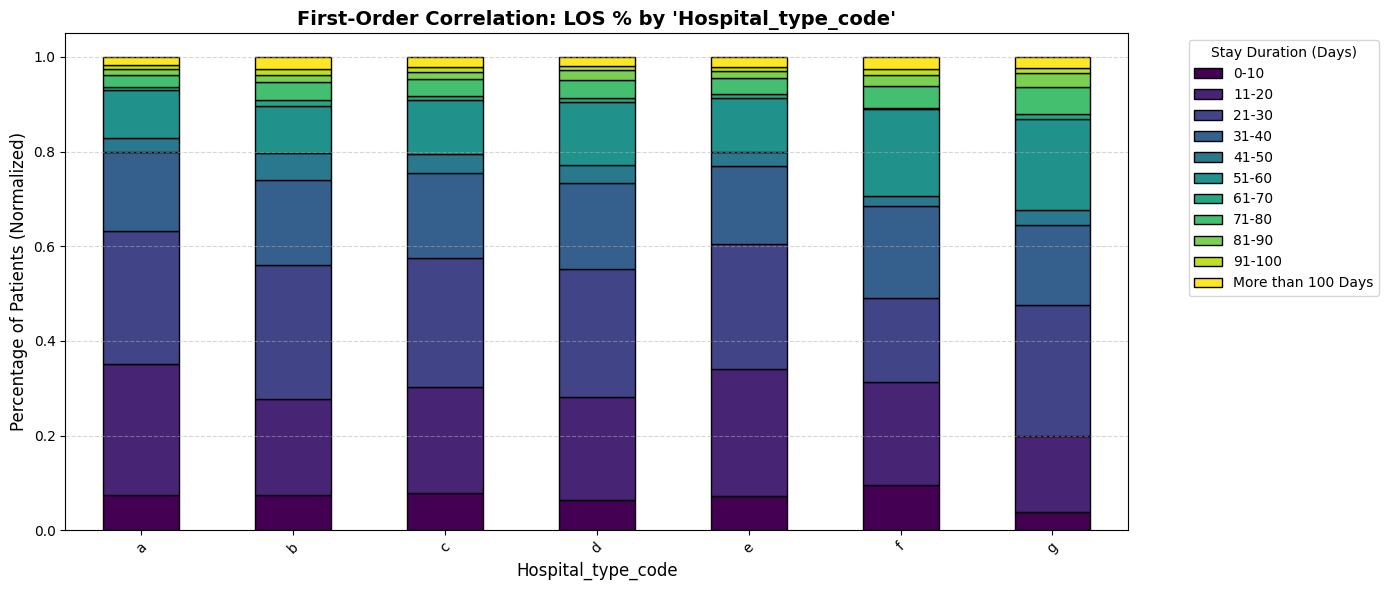



Likelihood (%) of Stay Duration based on 'Hospital_type_code'


Stay                0-10  11-20  21-30  31-40  41-50  51-60  61-70  71-80  81-90  91-100  More than 100 Days
Hospital_type_code                                                                                          
a                   7.38  27.81  28.11  16.68   2.85  10.16   0.64   2.59   1.32    0.67                1.78
b                   7.44  20.22  28.37  17.98   5.61  10.02   1.33   3.79   1.49    1.14                2.61
c                   7.79  22.49  27.30  17.91   4.08  11.28   0.93   3.49   1.58    0.95                2.19
d                   6.43  21.74  27.13  18.17   3.74  13.30   0.91   3.70   2.04    0.87                1.96
e                   7.27  26.84  26.46  16.33   3.08  11.37   0.79   3.36   1.58    0.89                2.03
f                   9.54  21.83  17.76  19.49   1.92  18.39   0.41   4.47   2.35    1.28                2.58
g                   3.92  16.00  27.73  16.83   3.26  19.07   

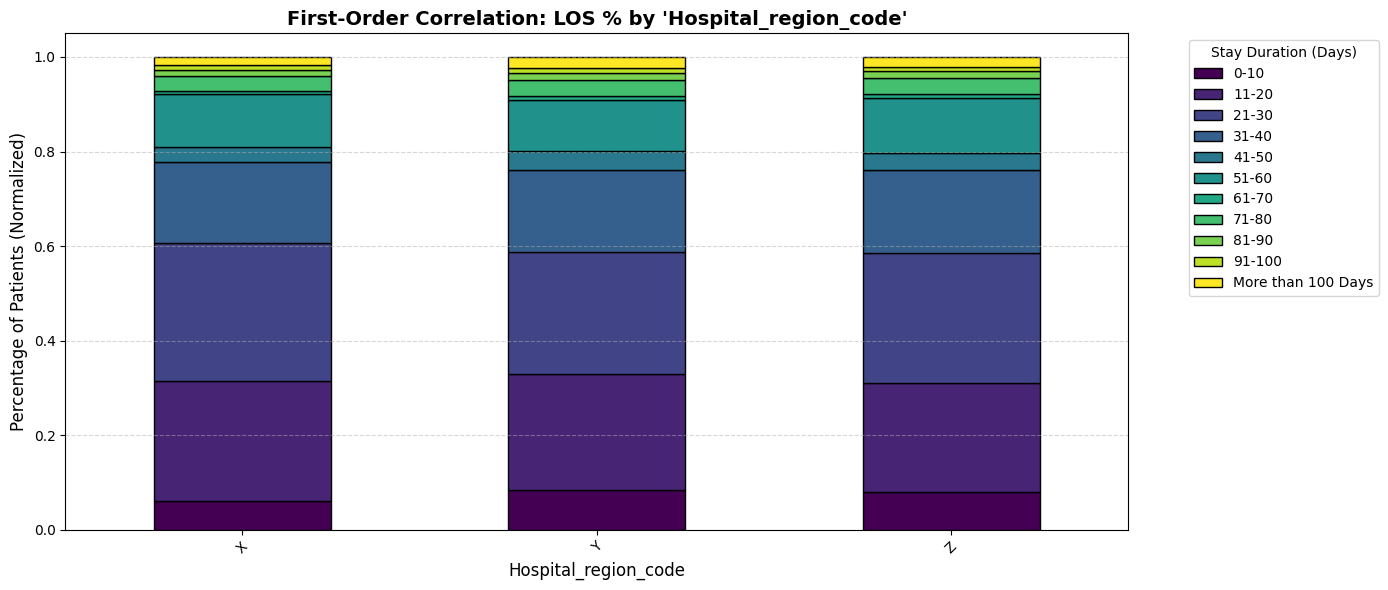



Likelihood (%) of Stay Duration based on 'Hospital_region_code'


Stay                  0-10  11-20  21-30  31-40  41-50  51-60  61-70  71-80  81-90  91-100  More than 100 Days
Hospital_region_code                                                                                          
X                     6.10  25.45  29.14  17.08   3.29  11.02   0.75   3.07   1.43    0.86                1.80
Y                     8.53  24.35  25.83  17.41   4.10  10.62   0.97   3.32   1.58    0.87                2.42
Z                     7.98  23.12  27.35  17.59   3.67  11.61   0.87   3.32   1.57    0.87                2.04




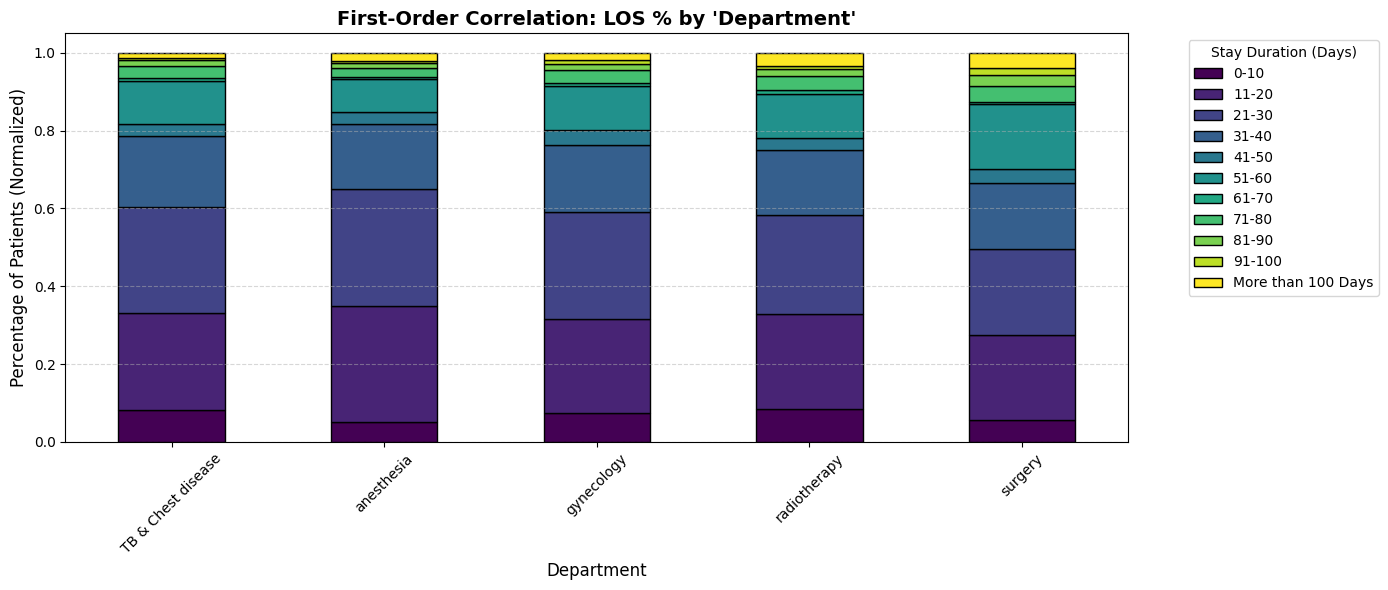



Likelihood (%) of Stay Duration based on 'Department'


Stay                0-10  11-20  21-30  31-40  41-50  51-60  61-70  71-80  81-90  91-100  More than 100 Days
Department                                                                                                  
TB & Chest disease  8.22  24.83  27.28  18.35   3.11  10.90   0.78   3.07   1.48    0.67                1.31
anesthesia          5.13  29.74  30.21  16.74   2.86   8.49   0.58   2.38   1.29    0.53                2.05
gynecology          7.55  23.96  27.45  17.43   3.87  11.21   0.89   3.27   1.50    0.91                1.98
radiotherapy        8.35  24.56  25.49  16.51   3.07  11.41   0.92   3.66   1.86    0.89                3.29
surgery             5.60  21.96  21.96  17.06   3.59  16.62   0.44   4.11   3.06    1.75                3.85




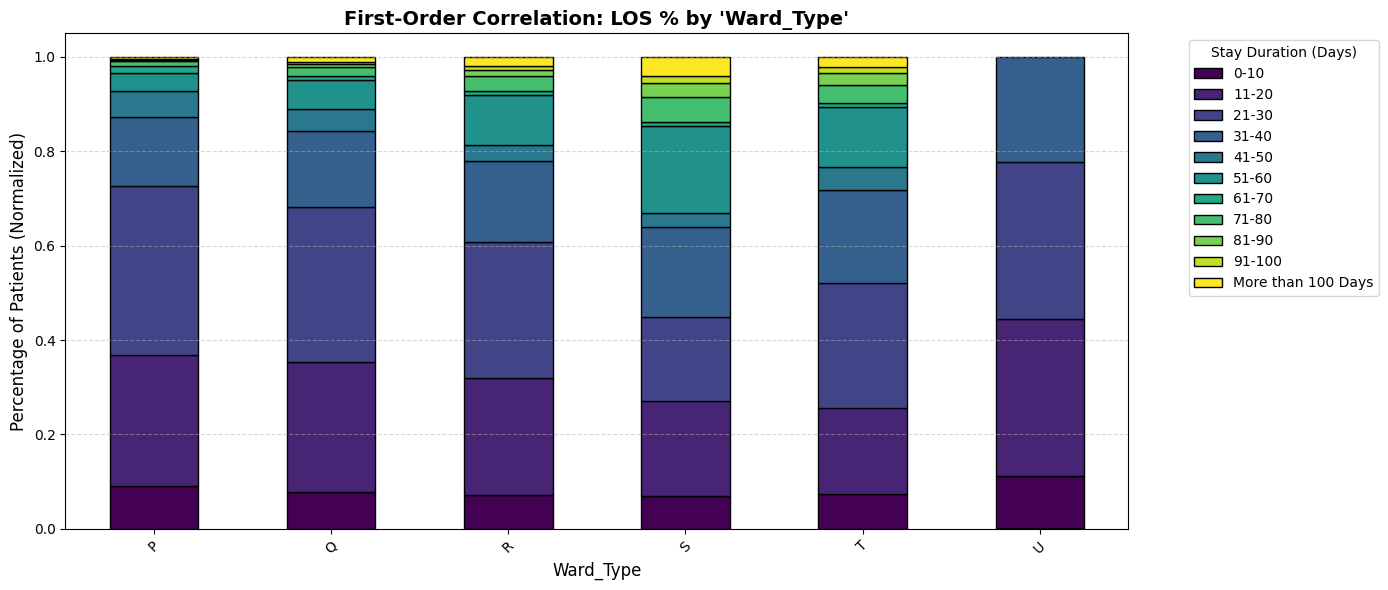



Likelihood (%) of Stay Duration based on 'Ward_Type'


Stay        0-10  11-20  21-30  31-40  41-50  51-60  61-70  71-80  81-90  91-100  More than 100 Days
Ward_Type                                                                                           
P           9.13  27.68  35.79  14.59   5.66   3.72   1.48   1.01   0.28    0.32                0.34
Q           7.85  27.56  32.75  16.17   4.64   6.07   0.93   1.84   0.74    0.43                1.01
R           7.26  24.74  28.74  17.21   3.33  10.72   0.81   3.13   1.32    0.87                1.87
S           6.94  20.14  17.83  19.16   2.79  18.53   0.80   5.37   2.95    1.47                4.02
T           7.44  18.16  26.55  19.73   4.71  12.76   0.89   3.75   2.59    1.37                2.05
U          11.11  33.33  33.33  22.22   0.00   0.00   0.00   0.00   0.00    0.00                0.00




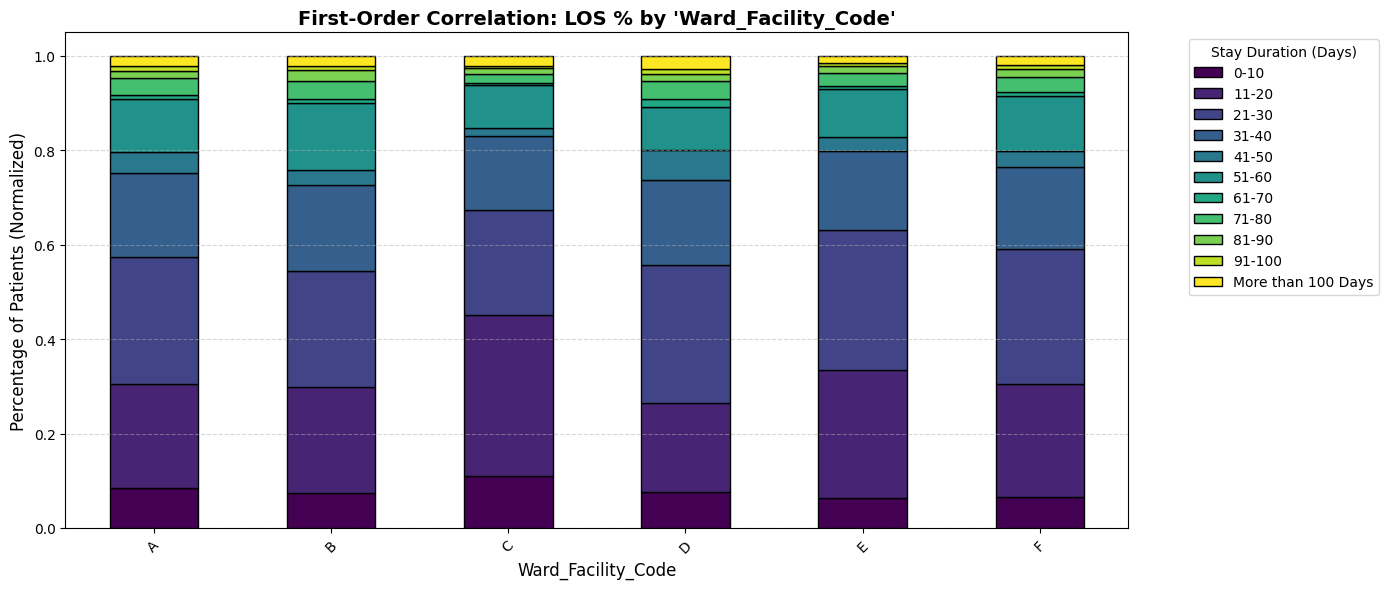



Likelihood (%) of Stay Duration based on 'Ward_Facility_Code'


Stay                 0-10  11-20  21-30  31-40  41-50  51-60  61-70  71-80  81-90  91-100  More than 100 Days
Ward_Facility_Code                                                                                           
A                    8.51  21.99  26.86  17.92   4.29  11.32   0.91   3.46   1.47    1.03                2.24
B                    7.39  22.42  24.57  18.23   3.12  14.40   0.71   3.92   2.18    0.95                2.10
C                   11.07  34.03  22.19  15.79   1.67   9.05   0.39   2.03   1.13    0.44                2.21
D                    7.55  19.02  29.17  17.96   6.44   9.13   1.54   3.81   1.49    1.10                2.78
E                    6.28  27.29  29.66  16.59   3.07  10.09   0.75   2.73   1.32    0.70                1.52
F                    6.47  24.12  28.45  17.40   3.36  11.73   0.78   3.28   1.55    0.90                1.96




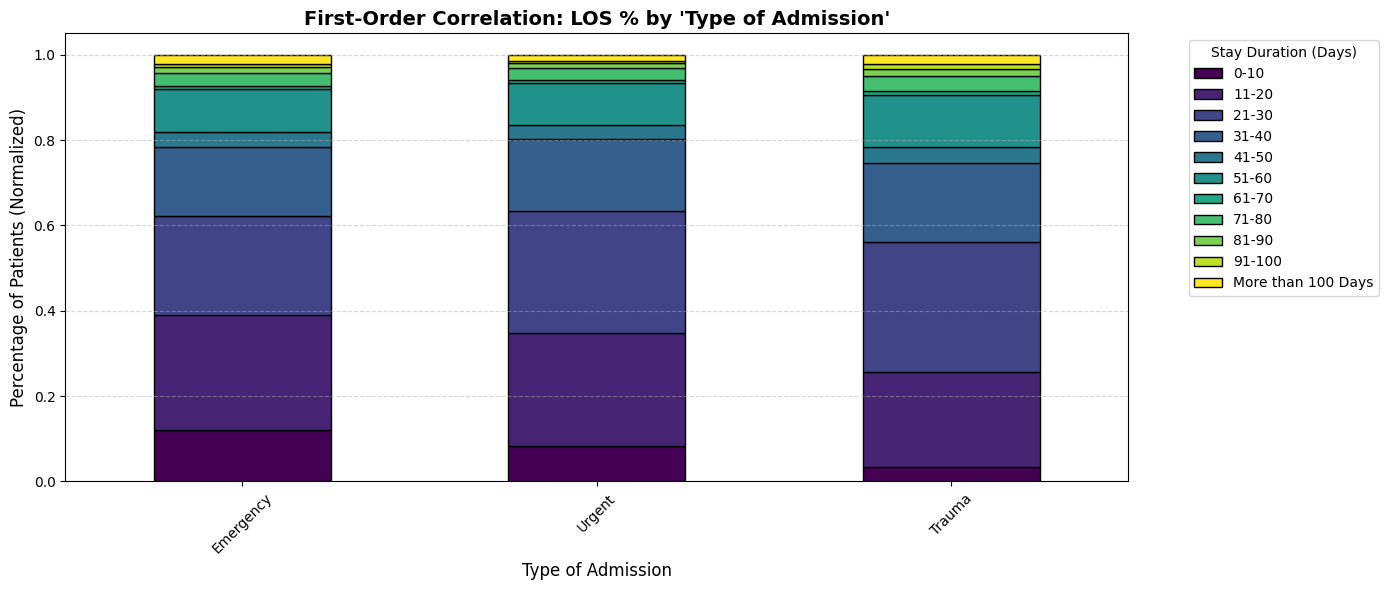



Likelihood (%) of Stay Duration based on 'Type of Admission'


Stay                0-10  11-20  21-30  31-40  41-50  51-60  61-70  71-80  81-90  91-100  More than 100 Days
Type of Admission                                                                                           
Emergency          12.11  26.91  23.28  16.05   3.50  10.07   0.82   2.85   1.45    0.79                2.16
Urgent              8.36  26.45  28.57  16.78   3.37   9.94   0.60   2.74   1.19    0.64                1.37
Trauma              3.49  22.17  30.42  18.45   3.91  12.01   0.97   3.65   1.67    0.99                2.26




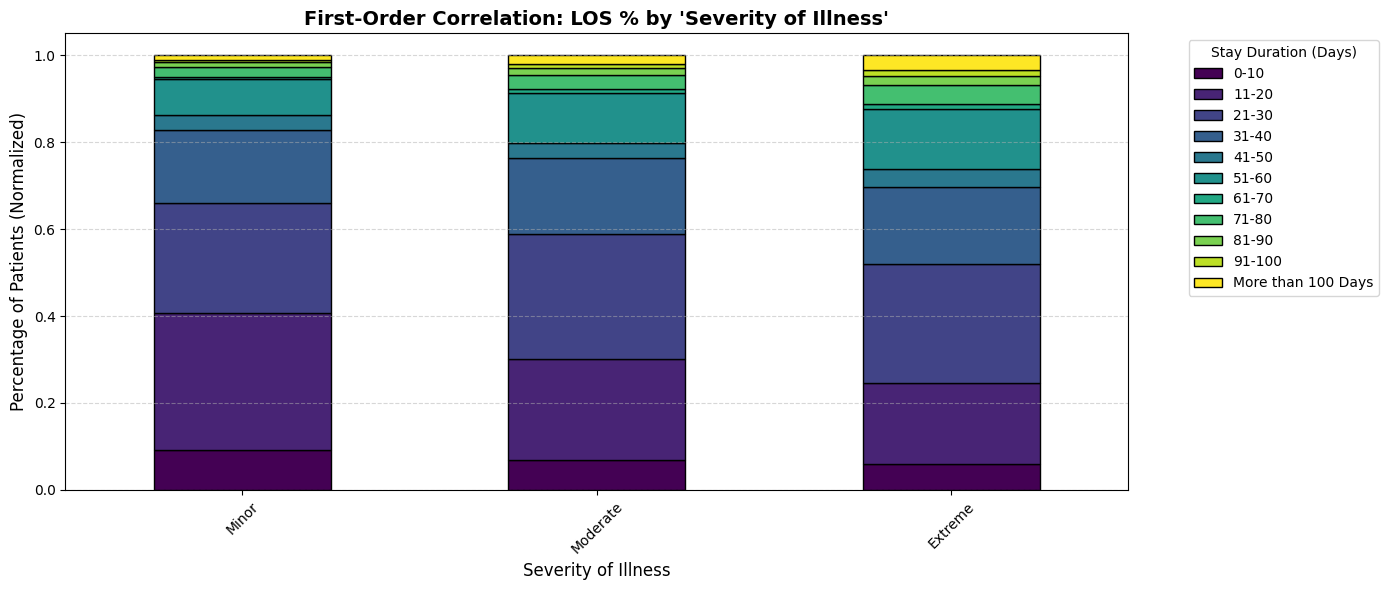



Likelihood (%) of Stay Duration based on 'Severity of Illness'


Stay                 0-10  11-20  21-30  31-40  41-50  51-60  61-70  71-80  81-90  91-100  More than 100 Days
Severity of Illness                                                                                          
Minor                9.19  31.62  25.11  16.76   3.48   8.27   0.60   2.23   1.14    0.50                1.10
Moderate             7.00  23.08  28.72  17.42   3.62  11.43   0.90   3.27   1.56    0.87                2.13
Extreme              5.99  18.56  27.35  17.79   4.14  13.70   1.14   4.54   1.96    1.41                3.42




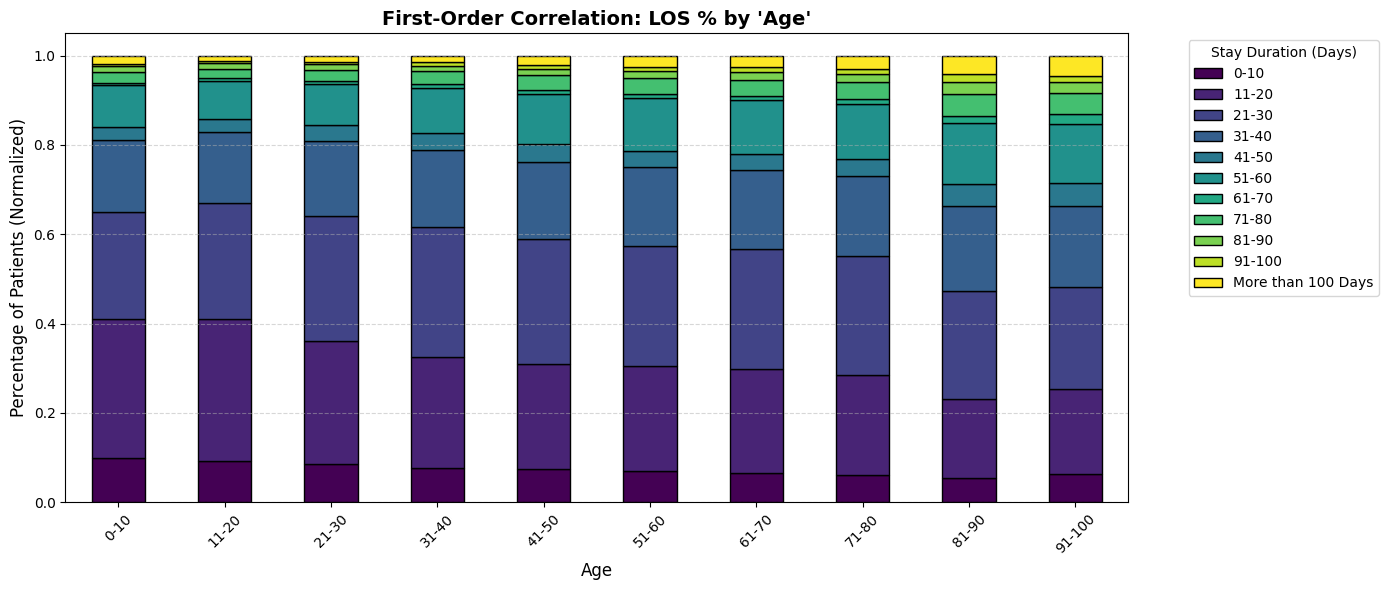



Likelihood (%) of Stay Duration based on 'Age'


Stay    0-10  11-20  21-30  31-40  41-50  51-60  61-70  71-80  81-90  91-100  More than 100 Days
Age                                                                                             
0-10    9.79  31.34  23.83  16.16   2.99   9.31   0.42   2.47   1.36    0.57                1.78
11-20   9.25  31.88  25.78  15.92   3.05   8.54   0.53   2.09   1.32    0.42                1.24
21-30   8.46  27.60  27.97  16.93   3.42   9.24   0.64   2.51   1.34    0.56                1.33
31-40   7.72  24.85  29.17  17.14   3.72  10.23   0.79   2.85   1.25    0.76                1.53
41-50   7.41  23.49  28.15  17.23   3.91  11.29   0.88   3.34   1.38    0.90                2.02
51-60   7.08  23.45  26.94  17.61   3.56  11.81   0.93   3.52   1.61    1.02                2.47
61-70   6.53  23.39  26.82  17.59   3.59  12.09   0.97   3.66   1.78    0.98                2.61
71-80   6.16  22.25  26.63  17.95   3.85  12.35   1.05   3.83   1.88    1.08

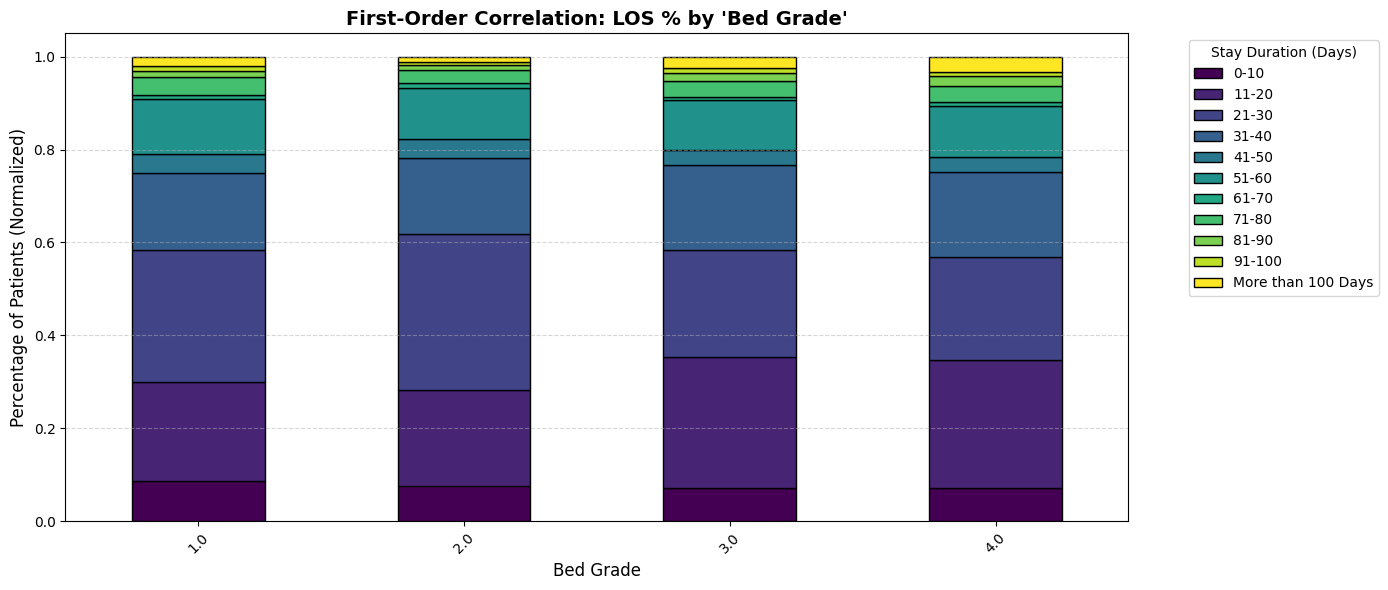



Likelihood (%) of Stay Duration based on 'Bed Grade'


Stay       0-10  11-20  21-30  31-40  41-50  51-60  61-70  71-80  81-90  91-100  More than 100 Days
Bed Grade                                                                                          
1.0        8.74  21.21  28.42  16.63   4.07  11.70   1.03   3.76   1.35    1.05                2.04
2.0        7.52  20.64  33.67  16.27   4.14  11.08   0.92   2.87   1.00    0.74                1.14
3.0        7.12  28.18  23.14  18.19   3.29  10.72   0.75   3.29   1.85    0.91                2.56
4.0        7.12  27.68  22.16  18.16   3.25  10.93   0.85   3.56   2.07    0.95                3.25


Generating charts for 5 second-order matrices...



/tmp/ipykernel_1471/2361168107.py:62: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pivot_table = dataframe.groupby([metric_a, metric_b])['Stay_Numeric_Rank'].mean().unstack() # this is the heatmap. It takes two metric and checks if a patient is in both and then takes the mean stay for this group.


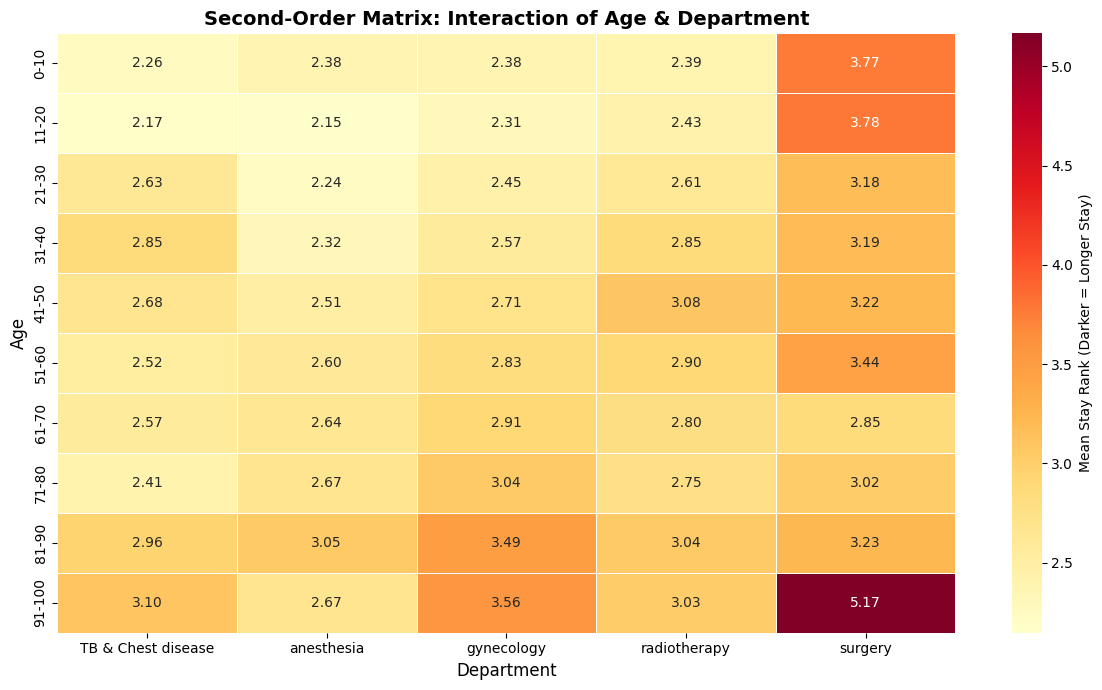



Mean Stay Rank for 'Age' and 'Department'


Range: from 0 (0-10 Days) to 10 (More than 100 Days)


Department  TB & Chest disease  anesthesia  gynecology  radiotherapy  surgery
Age                                                                          
0-10                      2.26        2.38        2.38          2.39     3.77
11-20                     2.17        2.15        2.31          2.43     3.78
21-30                     2.63        2.24        2.45          2.61     3.18
31-40                     2.85        2.32        2.57          2.85     3.19
41-50                     2.68        2.51        2.71          3.08     3.22
51-60                     2.52        2.60        2.83          2.90     3.44
61-70                     2.57        2.64        2.91          2.80     2.85
71-80                     2.41        2.67        3.04          2.75     3.02
81-90                     2.96        3.05        3.49          3.04     3.23
91-100                    3.10        2.6

/tmp/ipykernel_1471/2361168107.py:62: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pivot_table = dataframe.groupby([metric_a, metric_b])['Stay_Numeric_Rank'].mean().unstack() # this is the heatmap. It takes two metric and checks if a patient is in both and then takes the mean stay for this group.


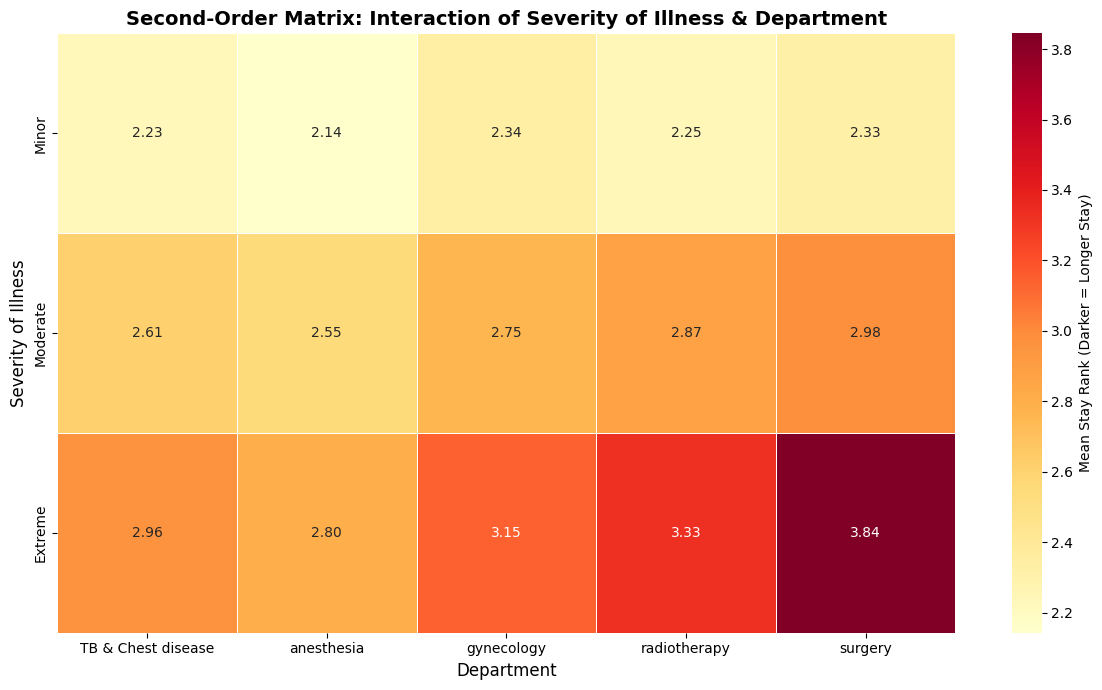



Mean Stay Rank for 'Severity of Illness' and 'Department'


Range: from 0 (0-10 Days) to 10 (More than 100 Days)


Department           TB & Chest disease  anesthesia  gynecology  radiotherapy  surgery
Severity of Illness                                                                   
Minor                              2.23        2.14        2.34          2.25     2.33
Moderate                           2.61        2.55        2.75          2.87     2.98
Extreme                            2.96        2.80        3.15          3.33     3.84


/tmp/ipykernel_1471/2361168107.py:62: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pivot_table = dataframe.groupby([metric_a, metric_b])['Stay_Numeric_Rank'].mean().unstack() # this is the heatmap. It takes two metric and checks if a patient is in both and then takes the mean stay for this group.


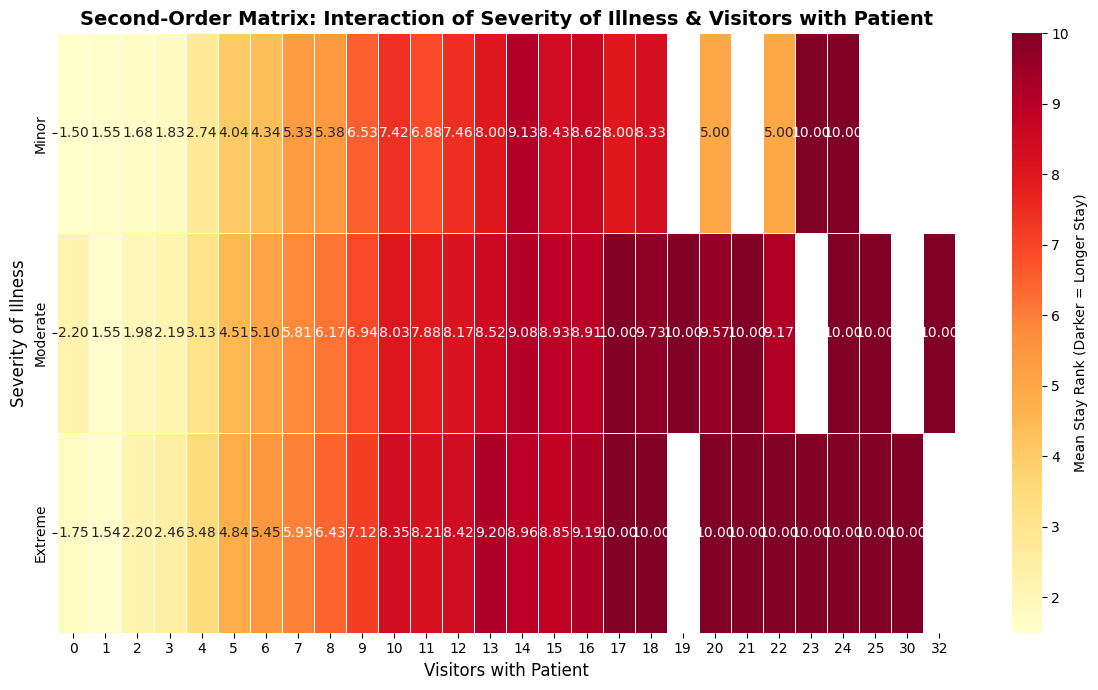



Mean Stay Rank for 'Severity of Illness' and 'Visitors with Patient'


Range: from 0 (0-10 Days) to 10 (More than 100 Days)


Visitors with Patient    0     1     2     3     4     5     6     7     8     9     10    11    12    13    14    15    16    17     18    19     20    21     22    23    24    25    30    32
Severity of Illness                                                                                                                                                                             
Minor                  1.50  1.55  1.68  1.83  2.74  4.04  4.34  5.33  5.38  6.53  7.42  6.88  7.46  8.00  9.13  8.43  8.62   8.0   8.33   NaN   5.00   NaN   5.00  10.0  10.0   NaN   NaN   NaN
Moderate               2.20  1.55  1.98  2.19  3.13  4.51  5.10  5.81  6.17  6.94  8.03  7.88  8.17  8.52  9.08  8.93  8.91  10.0   9.73  10.0   9.57  10.0   9.17   NaN  10.0  10.0   NaN  10.0
Extreme                1.75  1.54  2.20  2.46  3.48  4.84  5.45  5.93  6.43  7.12  8.35  8.21  8.42 

/tmp/ipykernel_1471/2361168107.py:62: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pivot_table = dataframe.groupby([metric_a, metric_b])['Stay_Numeric_Rank'].mean().unstack() # this is the heatmap. It takes two metric and checks if a patient is in both and then takes the mean stay for this group.


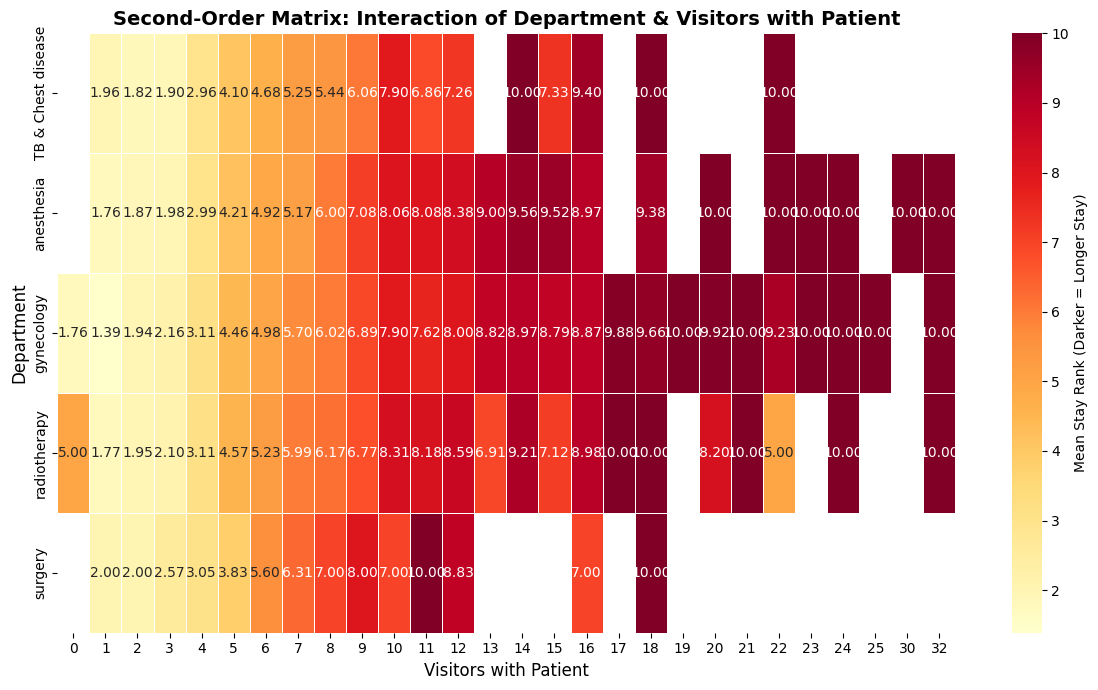



Mean Stay Rank for 'Department' and 'Visitors with Patient'


Range: from 0 (0-10 Days) to 10 (More than 100 Days)


Visitors with Patient    0     1     2     3     4     5     6     7     8     9     10     11    12    13     14    15    16     17     18    19     20    21     22    23    24    25    30    32
Department                                                                                                                                                                                         
TB & Chest disease      NaN  1.96  1.82  1.90  2.96  4.10  4.68  5.25  5.44  6.06  7.90   6.86  7.26   NaN  10.00  7.33  9.40    NaN  10.00   NaN    NaN   NaN  10.00   NaN   NaN   NaN   NaN   NaN
anesthesia              NaN  1.76  1.87  1.98  2.99  4.21  4.92  5.17  6.00  7.08  8.06   8.08  8.38  9.00   9.56  9.52  8.97    NaN   9.38   NaN  10.00   NaN  10.00  10.0  10.0   NaN  10.0  10.0
gynecology             1.76  1.39  1.94  2.16  3.11  4.46  4.98  5.70  6.02  6.89  7.90   7.62  8

/tmp/ipykernel_1471/2361168107.py:62: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pivot_table = dataframe.groupby([metric_a, metric_b])['Stay_Numeric_Rank'].mean().unstack() # this is the heatmap. It takes two metric and checks if a patient is in both and then takes the mean stay for this group.


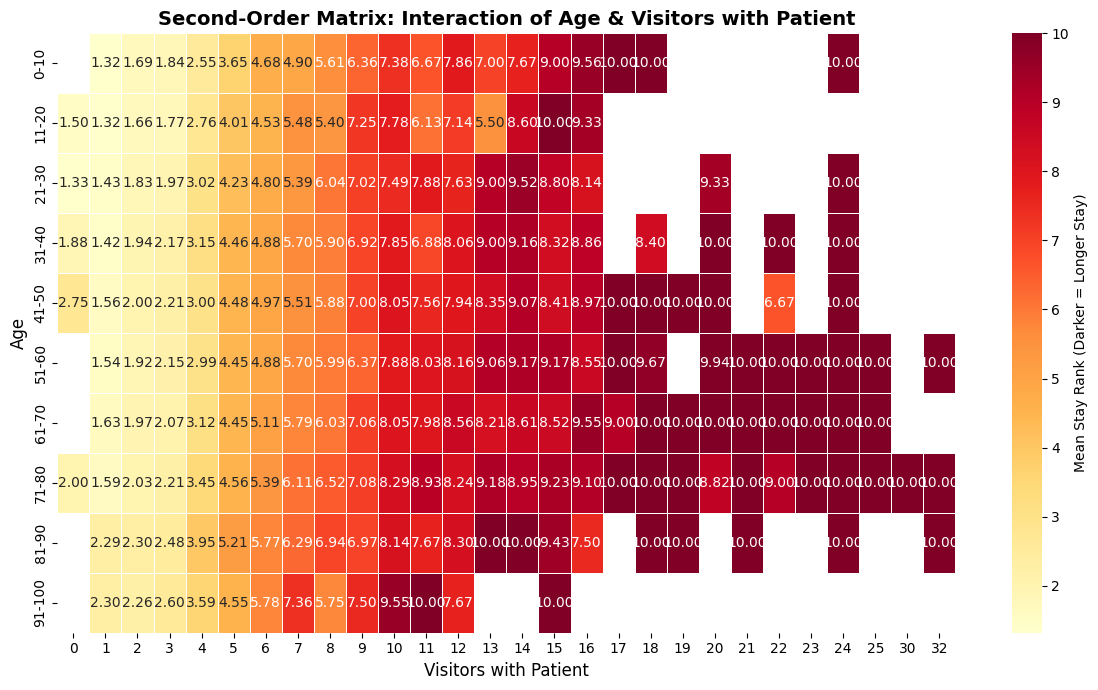



Mean Stay Rank for 'Age' and 'Visitors with Patient'


Range: from 0 (0-10 Days) to 10 (More than 100 Days)


Visitors with Patient    0     1     2     3     4     5     6     7     8     9     10     11    12     13     14     15    16    17     18    19     20    21     22    23    24    25    30    32
Age                                                                                                                                                                                                 
0-10                    NaN  1.32  1.69  1.84  2.55  3.65  4.68  4.90  5.61  6.36  7.38   6.67  7.86   7.00   7.67   9.00  9.56  10.0  10.00   NaN    NaN   NaN    NaN   NaN  10.0   NaN   NaN   NaN
11-20                  1.50  1.32  1.66  1.77  2.76  4.01  4.53  5.48  5.40  7.25  7.78   6.13  7.14   5.50   8.60  10.00  9.33   NaN    NaN   NaN    NaN   NaN    NaN   NaN   NaN   NaN   NaN   NaN
21-30                  1.33  1.43  1.83  1.97  3.02  4.23  4.80  5.39  6.04  7.02  7.49   7.88  7.63

In [ ]:
'''
This is code block 3. This prints the first order charts for each metric
some second order charts for a few combinations that I thought would be important.
'''

# Check to see if the functions are present. (Run Code Block 2)
if 'render_first_order_plot' not in globals():
    raise RuntimeError("Functions missing. You must run Cell 2 first.")

def generate_all_first_order_plots(dataframe):
    """
    Automatically cycles through every categorical feature and generates
    its stacked bar chart using the Cell 2 engine.
    """
    print(f" Generating charts for {len(CATEGORICAL_FEATURES)} first-order plots: \n")
    for column in CATEGORICAL_FEATURES:
        # Calls the function from Cell 2
        render_first_order_plot(dataframe, column)

def generate_sherry_second_order_heatmaps(dataframe):
    """
    generates heatmaps for some strategic metric combinations. (Not necessary)
    """
    # These are some metrics I think might be important for second order.
    strategic_combinations = [
        ('Age', 'Department'),
        ('Severity of Illness', 'Department'),
        ('Severity of Illness', 'Visitors with Patient'),
        ('Department', 'Visitors with Patient'),
        ('Age', 'Visitors with Patient')
    ]

    print(f"Generating charts for {len(strategic_combinations)} second-order matrices...\n")
    for metric_a, metric_b in strategic_combinations:
        # Calls the rendering engine from Cell 2
        render_second_order_heatmap(dataframe, metric_a, metric_b)

generate_all_first_order_plots(df)
generate_sherry_second_order_heatmaps(df)



Second Order Function Menu


[0] Hospital_type_code
[1] Hospital_region_code
[2] Department
[3] Ward_Type
[4] Ward_Facility_Code
[5] Type of Admission
[6] Severity of Illness
[7] Age
[8] Bed Grade
[9] Admission_Deposit
[10] Visitors with Patient
[11] Available Extra Rooms in Hospital


Variable A: 5
Variable B: 4


/tmp/ipykernel_1471/2361168107.py:62: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pivot_table = dataframe.groupby([metric_a, metric_b])['Stay_Numeric_Rank'].mean().unstack() # this is the heatmap. It takes two metric and checks if a patient is in both and then takes the mean stay for this group.


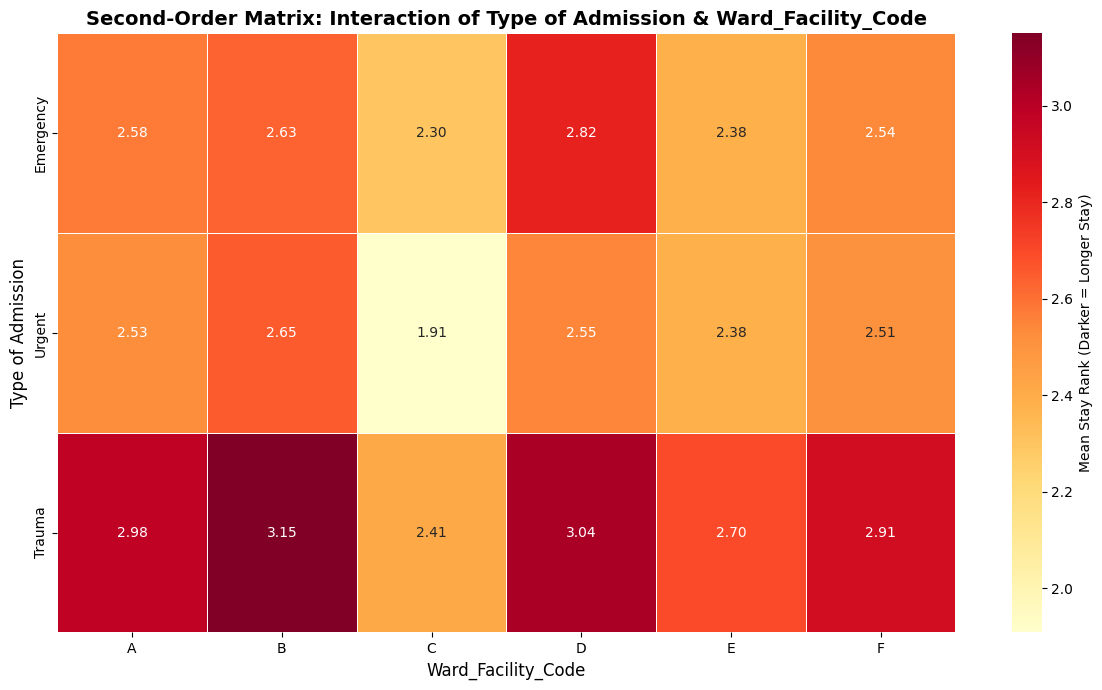



Mean Stay Rank for 'Type of Admission' and 'Ward_Facility_Code'


Range: from 0 (0-10 Days) to 10 (More than 100 Days)


Ward_Facility_Code     A     B     C     D     E     F
Type of Admission                                     
Emergency           2.58  2.63  2.30  2.82  2.38  2.54
Urgent              2.53  2.65  1.91  2.55  2.38  2.51
Trauma              2.98  3.15  2.41  3.04  2.70  2.91


In [ ]:
'''
This is code block 4. It serves a basic controller
for selecting what heatmap we want to produce.
'''

# Check to see if the functions are present. (Run Code Block 2)
if 'render_second_order_heatmap' not in globals():
    raise RuntimeError(" Functions missing. You must run Cell 2 first.")

def interactive_correlation_controller(dataframe):
    """
    Launches an interactive menu in the console allowing the user to select
    two variables and renders their respective heatmap.
    """
    # combining our global lists from Cell 1 so we dont have to re-type them
    all_available_metrics = CATEGORICAL_FEATURES + CONTINUOUS_FEATURES

    print("Second Order Function Menu")
    print("\n")
    for index, metric in enumerate(all_available_metrics):
        print(f"[{index}] {metric}")
    print("\n")

    # Selecting variable A
    try:
        selection_a = int(input("Variable A: "))
        if selection_a not in range(len(all_available_metrics)):
            print("Invalid selection. Run the cell again.")
            return
    except ValueError:
        print("Error: You must enter an integer number.")
        return

    # Selecting variable B
    try:
        selection_b = int(input("Variable B: "))
        if selection_b not in range(len(all_available_metrics)):
            print("Invalid selection. Run the cell again.")
            return
    except ValueError:
        print("Error: You must enter an integer number.")
        return

    # Extract the exact string names based on user input
    metric_a = all_available_metrics[selection_a]
    metric_b = all_available_metrics[selection_b]


    # call heatmap function with user input as parametres
    render_second_order_heatmap(dataframe, metric_a, metric_b)

interactive_correlation_controller(df)

     SELECT A METRIC TO VISUALIZE FIRST-ORDER     


[0] Hospital_type_code
[1] Hospital_region_code
[2] Department
[3] Ward_Type
[4] Ward_Facility_Code
[5] Type of Admission
[6] Severity of Illness
[7] Age
[8] Bed Grade
[9] Admission_Deposit
[10] Visitors with Patient
[11] Available Extra Rooms in Hospital


Which metric do you want: 2


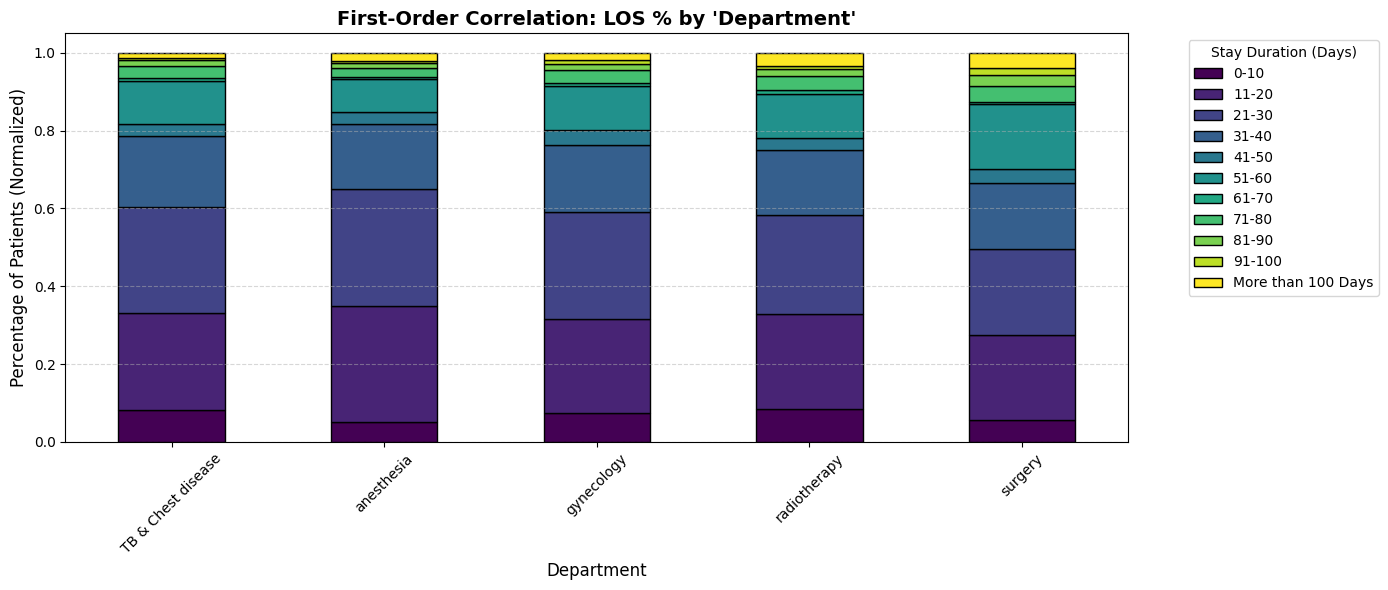



Likelihood (%) of Stay Duration based on 'Department'


Stay                0-10  11-20  21-30  31-40  41-50  51-60  61-70  71-80  81-90  91-100  More than 100 Days
Department                                                                                                  
TB & Chest disease  8.22  24.83  27.28  18.35   3.11  10.90   0.78   3.07   1.48    0.67                1.31
anesthesia          5.13  29.74  30.21  16.74   2.86   8.49   0.58   2.38   1.29    0.53                2.05
gynecology          7.55  23.96  27.45  17.43   3.87  11.21   0.89   3.27   1.50    0.91                1.98
radiotherapy        8.35  24.56  25.49  16.51   3.07  11.41   0.92   3.66   1.86    0.89                3.29
surgery             5.60  21.96  21.96  17.06   3.59  16.62   0.44   4.11   3.06    1.75                3.85




In [ ]:
'''
This is code block 5. It serves as a controller for us
to render specific first order graphs.
'''

# Check to see if the functions are present. (Run Code Block 2)
if 'render_first_order_plot' not in globals():
    raise RuntimeError("Functions missing. You must run Cell 2 first.")

def universal_first_order_controller(dataframe):
    """
    Interactive console menu for First-Order Stacked Bar Charts.
    Calls the first order function from code block 2.
    """
    # combining our global lists from Cell 1 so we dont have to re-type them
    all_available_metrics = CATEGORICAL_FEATURES + CONTINUOUS_FEATURES

    print("     SELECT A METRIC TO VISUALIZE FIRST-ORDER     ")
    print("\n")
    for index, column in enumerate(all_available_metrics):
        print(f"[{index}] {column}")
    print("\n")

    # Taking user input for specific metric
    try:
        user_choice = int(input("Which metric do you want: "))
        if user_choice not in range(len(all_available_metrics)):
            print("Invalid entry. Please run the cell again.")
            return
    except ValueError:
        print("Error: Input must be a valid integer number.")
        return

    selected_column = all_available_metrics[user_choice]

    # Call the first order function with user input as parametre
    render_first_order_plot(dataframe, selected_column)

universal_first_order_controller(df)

Median Calculator & Charts


[0] Admission_Deposit
[1] Visitors with Patient
[2] Available Extra Rooms in Hospital


Which metric's median would you like: 1


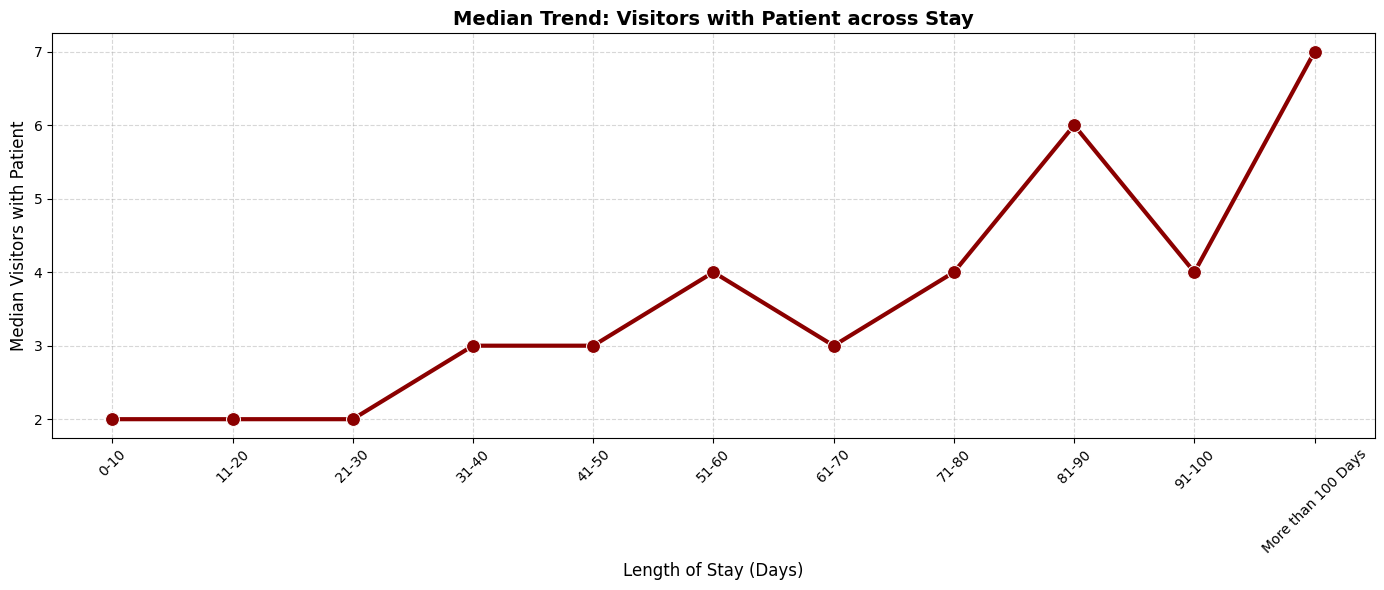



Exact Median 'Visitors with Patient' for each Stay category


              Stay  Visitors with Patient
              0-10                    2.0
             11-20                    2.0
             21-30                    2.0
             31-40                    3.0
             41-50                    3.0
             51-60                    4.0
             61-70                    3.0
             71-80                    4.0
             81-90                    6.0
            91-100                    4.0
More than 100 Days                    7.0




/tmp/ipykernel_1471/2361168107.py:108: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  stats_df = dataframe.groupby(TARGET_VAR)[continuous_metric].median().reset_index()


In [25]:
'''
This is code block 6. This is a median calculator and also shows a chart
for any continous function we would like. I'm not really sure about this function.
'''

# Check to see if the functions are present. (Run Code Block 2)
if 'render_median_trendline' not in globals():
    raise RuntimeError("Functions missing. You must run Cell 2 first.")

def interactive_median_trend_controller(dataframe):
    """
    Interactive console menu for plotting the median for continuous variables.
    Fucntion called from code block 2.
    """

    print("Median Calculator & Charts")
    print("\n")
    # produce menu for user input
    for index, column in enumerate(CONTINUOUS_FEATURES):
        print(f"[{index}] {column}")
    print("\n")

    # get user input
    try:
        user_choice = int(input("Which metric's median would you like: "))
        if user_choice not in range(len(CONTINUOUS_FEATURES)):
            print("Invalid entry. Please run the cell again.")
            return
    except ValueError:
        print("Error: Input must be a valid integer number.")
        return

    selected_column = CONTINUOUS_FEATURES[user_choice]

    # Call function from code block 2
    render_median_trendline(dataframe, selected_column)

interactive_median_trend_controller(df)

      SELECT A METRIC FOR DEEP-DIVE ANALYSIS      


[0] Hospital_type_code
[1] Hospital_region_code
[2] Department
[3] Ward_Type
[4] Ward_Facility_Code
[5] Type of Admission
[6] Severity of Illness
[7] Age
[8] Bed Grade


Which metric do you want to analyse: 5
What dates do you want to analyse: 


[0] 0-10
[1] 11-20
[2] 21-30
[3] 31-40
[4] 41-50
[5] 51-60
[6] 61-70
[7] 71-80
[8] 81-90
[9] 91-100
[10] More than 100 Days


Which stay Stay Duration do you want to analyse: 2


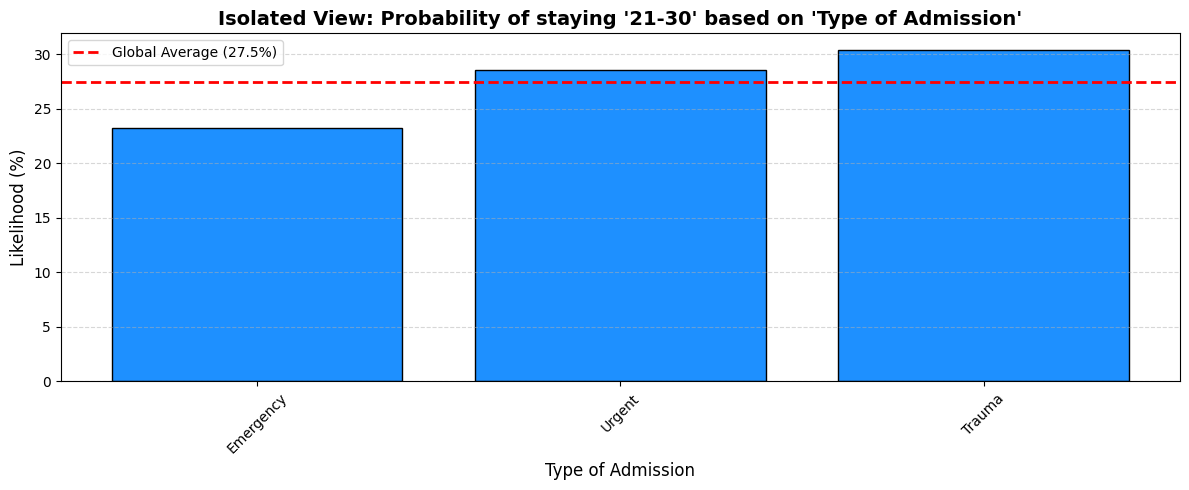


'21-30' grouped by 'Type of Admission'
Baseline Global Probability: 27.51% of all patients stay this long.
                   Total Patients  Stayed 21-30 (Count)  Likelihood (%)  Shift from Baseline (%)
Type of Admission                                                                               
Emergency                  115564                 26907           23.28                    -4.22
Urgent                      47977                 13709           28.57                     1.07
Trauma                     150252                 45700           30.42                     2.91



In [27]:
'''
This is code block 7
'''

# Check to see if the data has been loaded and the global variables are present. (Run Code Block 1)
if 'CATEGORICAL_FEATURES' not in globals():
    raise RuntimeError("Global features missing. You must run Cell 1 first.")

def isolated_first_order_deep_dive(dataframe):
    """
    Allows the user to visually isolate a single stay category to eliminate
    baseline shifting, and generates a detailed statistical matrix for context.
    """
    print("      SELECT A METRIC FOR DEEP-DIVE ANALYSIS      ")
    print("\n")
    # load up the metrics from the global categorical_features list in code block 1
    for index, column in enumerate(CATEGORICAL_FEATURES):
        print(f"[{index}] {column}")
    print("\n")

    # What metric do we want to specify
    try:
        var_choice = int(input("Which metric do you want to analyse: "))
        selected_metric = CATEGORICAL_FEATURES[var_choice]
    except (ValueError, IndexError):
        print("Invalid entry. Please run the cell again.")
        return

    # --- GET TARGET STAY DURATION ---
    # Pulls categories from stay_order list
    stay_categories = dataframe[TARGET_VAR].cat.categories.tolist()
    print("What dates do you want to analyse: ")
    print("\n")
    for index, stay in enumerate(stay_categories):
        print(f"[{index}] {stay}")
    print("\n")

    try:
        stay_choice = int(input(f"Which stay {TARGET_VAR} Duration do you want to analyse: "))
        selected_stay = stay_categories[stay_choice]
    except (ValueError, IndexError):
        print("Invalid entry. Please run the cell again.")
        return


    # The maths for the statistics:
    # 1. This finds the total patients that live for this specific duration
    global_prob = (len(dataframe[dataframe[TARGET_VAR] == selected_stay]) / len(dataframe)) * 100

    # 2. Builds the tables and normalises them
    crosstab_counts = pd.crosstab(dataframe[selected_metric], dataframe[TARGET_VAR])
    crosstab_percentages = crosstab_counts.div(crosstab_counts.sum(1), axis=0) * 100

    # The metric we care about
    isolated_percentages = crosstab_percentages[selected_stay]

    # Rendering the chart
    plt.figure(figsize=(12, 5))

    # Because it is only one variable, it sits flat on the X-axis. No visual shifting.
    bars = plt.bar(isolated_percentages.index.astype(str), isolated_percentages.values, color='dodgerblue', edgecolor='black')

    # Draw a red line showing the baseline global average
    plt.axhline(global_prob, color='red', linestyle='--', linewidth=2, label=f'Global Average ({global_prob:.1f}%)')

    plt.title(f"Isolated View: Probability of staying '{selected_stay}' based on '{selected_metric}'", fontsize=14, fontweight='bold')
    plt.ylabel(f"Likelihood (%)", fontsize=12)
    plt.xlabel(selected_metric, fontsize=12)
    plt.xticks(rotation=45)
    plt.legend()
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

    # Printing mathematical context
    print("\n" + "="*70)
    print(f"'{selected_stay}' grouped by '{selected_metric}'")
    print(f"Baseline Global Probability: {global_prob:.2f}% of all patients stay this long.")
    print("="*70)

    # This build a clean output talbe
    stats_df = pd.DataFrame({
        'Total Patients': crosstab_counts.sum(axis=1),
        f'Stayed {selected_stay} (Count)': crosstab_counts[selected_stay],
        'Likelihood (%)': isolated_percentages.round(2),
        'Shift from Baseline (%)': (isolated_percentages - global_prob).round(2)
    })

    print(stats_df.to_string())
    print("="*70 + "\n")

isolated_first_order_deep_dive(df)